In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Timing of event

In [10]:
idate = '2014-10-12'
fdate = '2014-10-15'
dom='CH'

# load tp data

In [11]:
tp = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/chirps/daily/chirps-v2.0.2014.days_p05_HMA.nc')
tp = tp.sel(time=slice(idate,fdate))
tp = field_dom(tp,dom)

In [12]:
tp

<xarray.Dataset> Size: 554kB
Dimensions:    (time: 4, longitude: 230, latitude: 150)
Coordinates:
  * time       (time) datetime64[ns] 32B 2014-10-12 2014-10-13 ... 2014-10-15
  * longitude  (longitude) float32 920B 80.02 80.08 80.12 ... 91.38 91.42 91.48
  * latitude   (latitude) float32 600B 23.02 23.07 23.12 ... 30.38 30.42 30.47
Data variables:
    precip     (time, latitude, longitude) float32 552kB ...
Attributes: (12/17)
    CDI:               Climate Data Interface version 2.0.4 (https://mpimet.m...
    Conventions:       CF-1.6
    institution:       Climate Hazards Group.  University of California at Sa...
    title:             CHIRPS Version 2.0
    history:           Wed May 21 21:06:40 2025: cdo sellonlatbox,60,110,20,4...
    version:           Version 2.0
    ...                ...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ
    CDO:               Climate Data Operators version 2.0.4 (https://mpimet.m...

# elev data

In [13]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
elev = field_dom(elev,dom)

In [14]:
latS,latN,lonW,lonE = coord_domain(dom)

# Spatial Precipitation over event

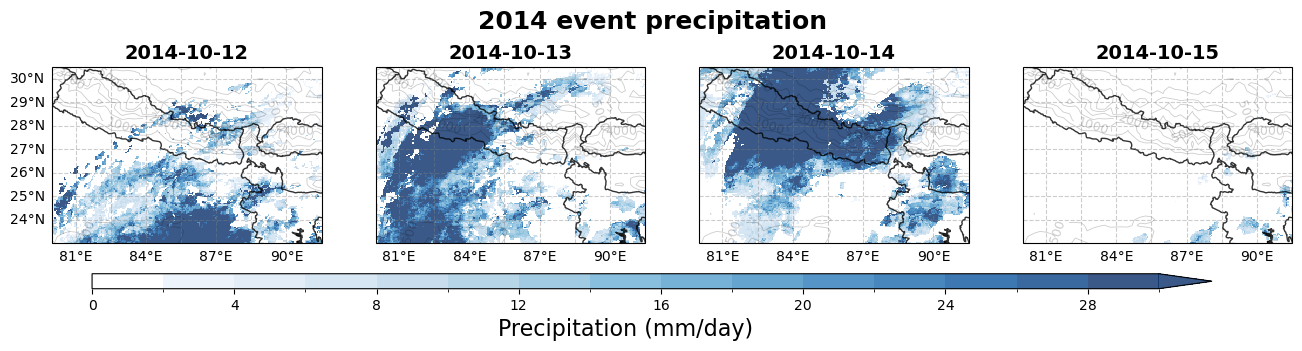

In [15]:
#==================== Color grading ============================

step = 2
vmax = 30
levels = np.arange(0, vmax + step, step)

base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

#===================== Plot each day ==================

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 3),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    
    data_day = tp.precip.isel(time=i)
    date = str(tp.time.values[i])[:10]

    im = ax.pcolormesh(
        tp.longitude,
        tp.latitude,
        data_day,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto",
        alpha=0.8
    )

    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    # === contours topo (si dispo) ===
    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

    ax.set_title(date, fontsize=14, weight="bold")

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.4,
        linestyle="--"
    )

    if i==0:
        gl.left_labels = True
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False
    elif i in [1,2,3]:
        gl.left_labels = False
        gl.bottom_labels = True
        gl.top_labels = False
        gl.right_labels = False

#==================== Colorbar ============================

cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("Precipitation (mm/day)", fontsize=16)

#==================== Final ============================

plt.suptitle("2014 event precipitation", fontsize=18, weight="bold")
plt.show()